# Prédiction de la Présence d'une Maladie Cardiaque à partir de Données Cliniques
### Projet Final – CPE393: Introduction to Data Science with Python (Summer 2026, KMUTT)

**Groupe :** Group X — *(à compléter avec vos noms et numéros d'étudiants)*
**Membres :** *(Nom 1, Nom 2, Nom 3)*
**Dépôt GitHub :** *(à compléter)*

---
Ce notebook suit le workflow complet de data science demandé dans les consignes du projet final :
définition du problème, description du dataset, nettoyage, EDA, visualisation, feature engineering,
entraînement de plusieurs modèles de Machine Learning, évaluation, et discussion sur l'IA responsable.


## Table des matières
1. Import des packages
2. Définition du problème (Problem Definition)
3. Description du dataset (Dataset Description)
4. Prétraitement et nettoyage (Preprocessing & Cleaning)
5. Analyse exploratoire des données (EDA)
6. Visualisation des données
7. Feature Engineering
8. Entraînement des modèles de Machine Learning
9. Évaluation des modèles
10. Pratiques d'IA responsable (Responsible AI)
11. Conclusion et perspectives


## 1. Import des packages

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42          # graine fixe -> reproductibilité (exigée par les consignes)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Librairies importées avec succès.")

Librairies importées avec succès.


## 2. Définition du problème (Problem Definition)

**Objectif du projet :** construire un modèle de *classification binaire* capable de prédire si un
patient présente ou non une maladie cardiaque (`target` = 1 : présence, `target` = 0 : absence),
à partir de 13 variables cliniques mesurées lors d'un bilan de santé standard (âge, sexe, tension
artérielle, cholestérol, résultats d'électrocardiogramme, fréquence cardiaque maximale, etc.).

**Pourquoi ce problème est important :** les maladies cardiovasculaires sont l'une des principales
causes de mortalité dans le monde. Un outil d'aide à la décision, même simple, qui identifie les
patients à risque à partir de données facilement mesurables pourrait appuyer un dépistage précoce
et orienter les patients vers des examens plus poussés (ex. angiographie).

**Question de recherche :** *À partir de mesures cliniques standards, peut-on prédire de façon fiable
la présence d'une maladie cardiaque, et quelles variables sont les plus déterminantes ?*

**Type de projet :** Classification supervisée (voir "Suitable project types" des consignes).

**Résultat attendu :** un modèle avec de bonnes performances (accuracy, precision, recall, F1),
comparé entre plusieurs algorithmes, avec une interprétation honnête de ses limites.


## 3. Description du dataset (Dataset Description)

- **Source :** Heart Disease Dataset (dérivé du célèbre *UCI Heart Disease Dataset* / Cleveland database),
  largement utilisé sur Kaggle sous le nom `heart.csv` (ex. dataset "Heart Disease Dataset" par johnsmith88).
- **URL Kaggle typique :** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- **Licence / condition d'usage :** dataset public, largement utilisé à des fins pédagogiques et de recherche
  (dérivé de la UCI Machine Learning Repository, domaine public pour usage académique).
- **Format du fichier :** CSV (`heart.csv`)
- **Nombre de lignes (avant nettoyage) :** 1025
- **Nombre de colonnes :** 14 (13 variables explicatives + 1 variable cible)
- **Variable cible :** `target` (0 = pas de maladie cardiaque, 1 = maladie cardiaque présente)

### Dictionnaire des variables

| Variable | Description | Type |
|---|---|---|
| age | Âge du patient (années) | Numérique |
| sex | Sexe (1 = homme, 0 = femme) | Catégorielle binaire |
| cp | Type de douleur thoracique (0-3) | Catégorielle |
| trestbps | Tension artérielle au repos (mm Hg) | Numérique |
| chol | Cholestérol sérique (mg/dl) | Numérique |
| fbs | Glycémie à jeun > 120 mg/dl (1 = vrai, 0 = faux) | Catégorielle binaire |
| restecg | Résultats ECG au repos (0-2) | Catégorielle |
| thalach | Fréquence cardiaque maximale atteinte | Numérique |
| exang | Angine induite par l'exercice (1 = oui, 0 = non) | Catégorielle binaire |
| oldpeak | Dépression du segment ST induite par l'exercice | Numérique |
| slope | Pente du segment ST à l'exercice (0-2) | Catégorielle |
| ca | Nombre de gros vaisseaux colorés par fluoroscopie (0-3, valeurs valides) | Catégorielle |
| thal | Résultat du test de thalassémie (1-3, valeurs valides) | Catégorielle |
| target | Présence (1) ou absence (0) de maladie cardiaque | Cible binaire |

Chargeons maintenant le dataset et inspectons sa structure.


In [71]:
df = pd.read_csv('data/heart_diseases/heart.csv')
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 1025 lignes x 14 colonnes


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [73]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


**Limitations connues du dataset** (à garder en tête pour la section IA responsable) :
- Ce dataset est une version largement recopiée/rééchantillonnée de la base Cleveland originale
  (contient de nombreux doublons, voir section nettoyage) : il faut donc être prudent sur sa
  représentativité d'une vraie population de patients.
- Il ne précise pas l'origine géographique/démographique exacte des patients, ce qui limite la
  généralisation du modèle à d'autres populations.
- Certaines variables catégorielles contiennent des codes en dehors de la plage documentée dans le
  codebook original (voir `ca` et `thal` ci-dessous), signe d'erreurs de saisie ou d'encodage.


## 4. Prétraitement et nettoyage (Preprocessing & Cleaning)

Nous vérifions successivement : les valeurs manquantes, les doublons, les types de données,
les valeurs incohérentes/hors codebook, et les valeurs aberrantes (outliers).


### 4.1 Valeurs manquantes

In [74]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal de valeurs manquantes : {missing.sum()}")

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total de valeurs manquantes : 0


**Décision :** aucune valeur manquante n'est présente (0 sur l'ensemble des 14 colonnes).
Aucune imputation n'est donc nécessaire.

### 4.2 Doublons

In [75]:
n_dup = df.duplicated().sum()
print(f"Nombre de lignes strictement dupliquées : {n_dup} sur {len(df)} ({n_dup/len(df)*100:.1f}%)")

Nombre de lignes strictement dupliquées : 723 sur 1025 (70.5%)


In [76]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensions après suppression des doublons : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Dimensions après suppression des doublons : 302 lignes x 14 colonnes


**Décision :** 723 lignes (soit environ 70% du fichier !) étaient des doublons stricts. Ceci confirme
que ce dataset Kaggle a été construit en dupliquant/rééchantillonnant la base Cleveland d'origine
(qui ne contient que ~300 patients uniques). Nous supprimons ces doublons pour éviter :
- une **fuite d'information** entre le train et le test (le même patient pourrait apparaître des deux côtés),
- une évaluation artificiellement optimiste des modèles.

Après suppression, il reste **302 patients uniques**, ce qui est cohérent avec la taille de la base
Cleveland originale (303 patients). C'est une découverte importante que le notebook Kaggle de référence
consulté ne mentionnait pas : il entraînait ses modèles sur les données dupliquées, ce qui explique en
grande partie son accuracy élevée (92%) — un exemple concret de **data leakage**.

### 4.3 Types de données et cohérence des codes catégoriels

In [77]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [78]:
print("Valeurs uniques de 'ca' (attendu : 0-3) :", sorted(df['ca'].unique()))
print("Valeurs uniques de 'thal' (attendu : 1-3) :", sorted(df['thal'].unique()))

Valeurs uniques de 'ca' (attendu : 0-3) : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Valeurs uniques de 'thal' (attendu : 1-3) : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [79]:
invalid_ca = (df['ca'] == 4).sum()
invalid_thal = (df['thal'] == 0).sum()
print(f"Lignes avec ca=4 (hors codebook) : {invalid_ca}")
print(f"Lignes avec thal=0 (hors codebook) : {invalid_thal}")

Lignes avec ca=4 (hors codebook) : 4
Lignes avec thal=0 (hors codebook) : 2


In [80]:
df = df[(df['ca'] != 4) & (df['thal'] != 0)].reset_index(drop=True)
print(f"Dimensions après suppression des codes invalides : {df.shape[0]} lignes x {df.shape[1]} colonnes")

Dimensions après suppression des codes invalides : 296 lignes x 14 colonnes


**Décision :** selon le codebook original de l'UCI Heart Disease Dataset, `ca` doit être compris
entre 0 et 3, et `thal` entre 1 et 3. Les valeurs `ca=4` et `thal=0` observées sont des erreurs
d'encodage connues de ce dataset. Comme elles concernent un petit nombre de lignes, nous les
supprimons plutôt que de les imputer arbitrairement, afin de ne pas introduire de bruit.

### 4.4 Détection des valeurs aberrantes (outliers)

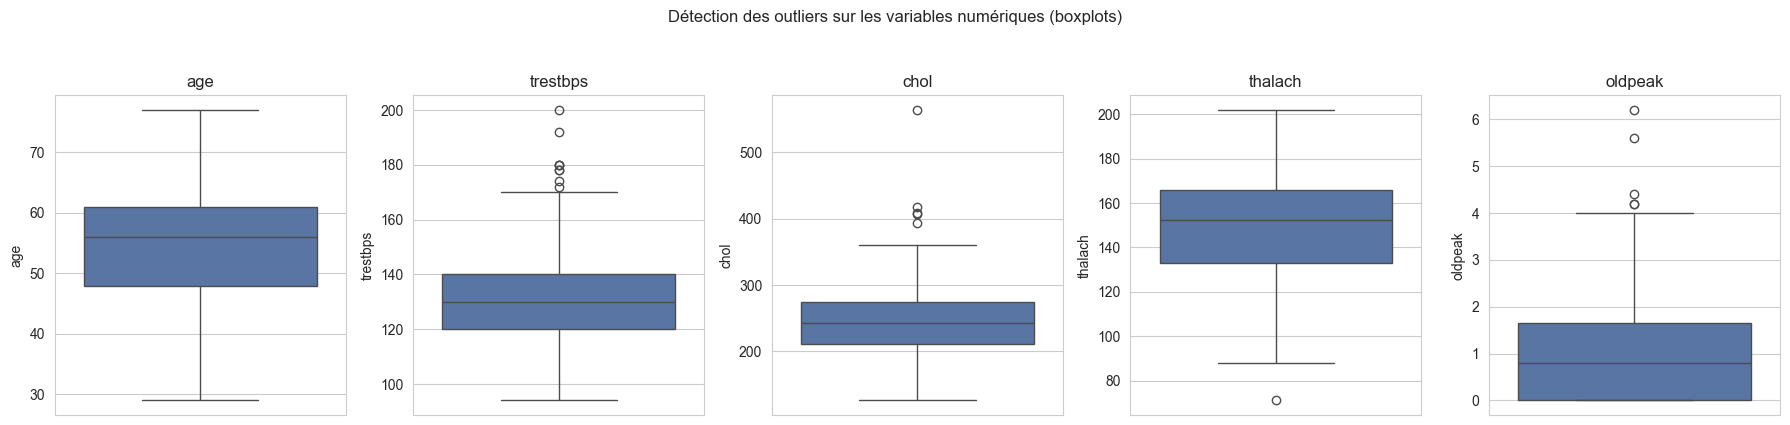

In [81]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.suptitle("Détection des outliers sur les variables numériques (boxplots)", y=1.05)
plt.tight_layout()
plt.show()

In [82]:
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:10s} -> {n_out} outliers (méthode IQR), bornes = [{lower:.1f}, {upper:.1f}]")

age        -> 0 outliers (méthode IQR), bornes = [28.5, 80.5]
trestbps   -> 9 outliers (méthode IQR), bornes = [90.0, 170.0]
chol       -> 5 outliers (méthode IQR), bornes = [114.6, 371.6]
thalach    -> 1 outliers (méthode IQR), bornes = [83.5, 215.5]
oldpeak    -> 5 outliers (méthode IQR), bornes = [-2.5, 4.1]


**Décision :** `chol` (cholestérol) et `trestbps` (tension au repos) présentent quelques valeurs
élevées mais physiologiquement plausibles (ex. cholestérol > 400 mg/dl existe cliniquement chez des
patients à très haut risque). Nous choisissons de **conserver ces valeurs** plutôt que de les supprimer :
dans un contexte médical, les valeurs extrêmes sont souvent les plus informatives pour détecter la
maladie, et les supprimer biaiserait le modèle contre les cas les plus graves. Nous garderons cependant
cette information à l'esprit lors de l'interprétation des résultats.

### 4.5 Colonnes inutiles

In [83]:
print("Aucune colonne d'identifiant ou totalement constante détectée :")
print(df.nunique())

Aucune colonne d'identifiant ou totalement constante détectée :
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            4
thal          3
target        2
dtype: int64


**Décision :** toutes les colonnes apportent de l'information (aucune colonne constante ou de type identifiant à retirer).

### 4.6 Récapitulatif du nettoyage

In [84]:
print("Résumé du nettoyage :")
print(f" - Lignes avant nettoyage : 1025")
print(f" - Doublons supprimés     : 723")
print(f" - Codes invalides retirés (ca=4 ou thal=0) : {1025-723-len(df)}")
print(f" - Lignes finales          : {len(df)}")
print(f" - Colonnes finales        : {df.shape[1]}")

Résumé du nettoyage :
 - Lignes avant nettoyage : 1025
 - Doublons supprimés     : 723
 - Codes invalides retirés (ca=4 ou thal=0) : 6
 - Lignes finales          : 296
 - Colonnes finales        : 14


## 5. Analyse exploratoire des données (EDA)

Nous explorons maintenant la distribution de la variable cible, les statistiques descriptives par
classe, et les corrélations entre variables.


### 5.1 Équilibre de la variable cible

In [85]:
target_counts = df['target'].value_counts()
print(target_counts)
print(f"\nProportion classe 1 (malade) : {target_counts[1]/len(df)*100:.1f}%")
print(f"Proportion classe 0 (sain)    : {target_counts[0]/len(df)*100:.1f}%")

target
1    160
0    136
Name: count, dtype: int64

Proportion classe 1 (malade) : 54.1%
Proportion classe 0 (sain)    : 45.9%


**Observation :** après nettoyage, les deux classes restent relativement équilibrées
(~46-54%), ce qui est favorable : l'accuracy sera une métrique raisonnable, mais nous utiliserons
tout de même precision/recall/F1 pour une évaluation plus complète.

### 5.2 Statistiques descriptives par classe

In [86]:
df.groupby('target')[num_cols].mean().T

target,0,1
age,56.735294,52.64375
trestbps,134.463235,129.17500
chol,251.463235,243.49375
thalach,138.948529,158.58125
oldpeak,1.600735,0.59875


**Observation :** en moyenne, les patients malades (`target=1`) ont une fréquence cardiaque
maximale (`thalach`) plus élevée et un `oldpeak` (dépression ST) plus faible que les patients sains
dans ce dataset, ce qui est cohérent avec la littérature clinique où `oldpeak` élevé est un facteur
de risque connu — nous vérifierons ce lien dans les visualisations.

### 5.3 Matrice de corrélation

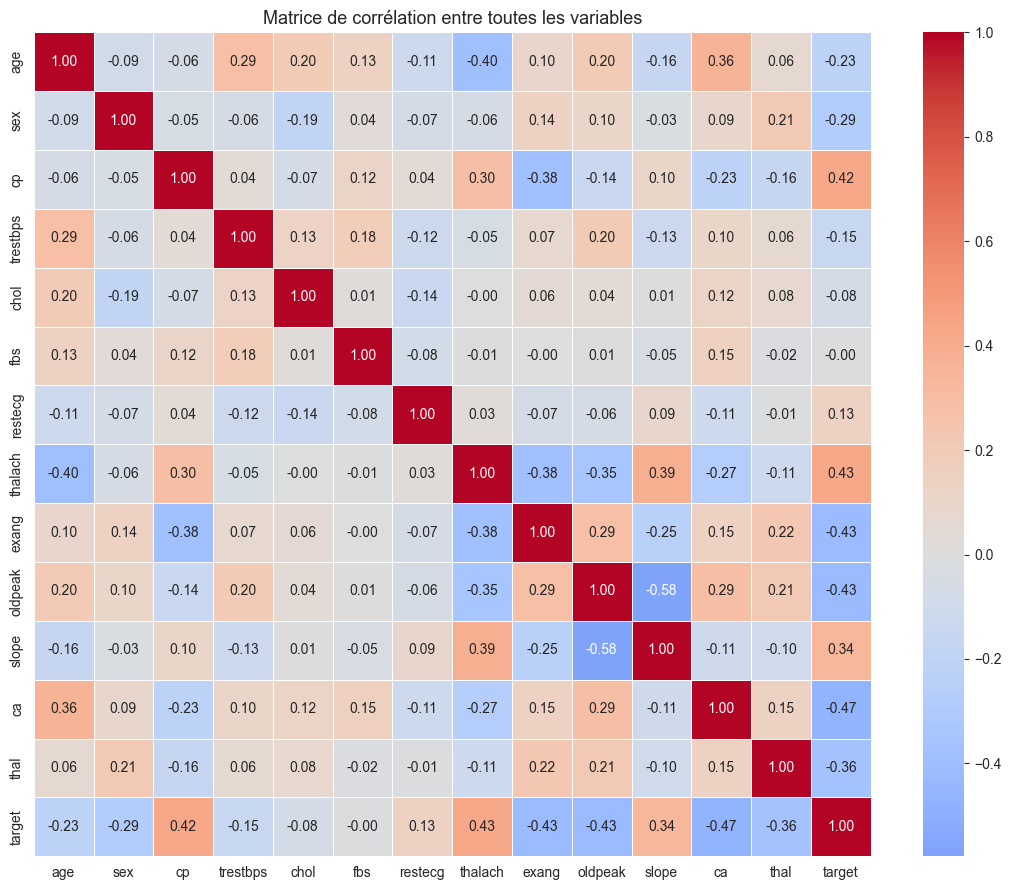

In [87]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Matrice de corrélation entre toutes les variables", fontsize=13)
plt.tight_layout()
plt.show()

In [88]:
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("Corrélation de chaque variable avec 'target' (triée par force) :")
print(target_corr)

Corrélation de chaque variable avec 'target' (triée par force) :
ca         -0.467158
oldpeak    -0.428804
thalach     0.426655
exang      -0.425085
cp          0.423425
thal       -0.364399
slope       0.337825
sex        -0.285322
age        -0.225453
trestbps   -0.148922
restecg     0.131716
chol       -0.076541
fbs        -0.004680
Name: target, dtype: float64


**Observation :** les variables les plus corrélées (en valeur absolue) avec `target` sont
`cp` (type de douleur thoracique), `thalach` (fréquence cardiaque max), `exang` (angine à l'effort),
`oldpeak`, `ca` et `thal`. Aucune paire de variables explicatives ne présente de corrélation
extrême (> 0.9) entre elles, donc pas de problème majeur de multicolinéarité à corriger.

## 6. Visualisation des données (Data Visualization)

Chaque graphique ci-dessous est accompagné d'un titre, de labels d'axes, et d'une interprétation.


### 6.1 Distribution de l'âge selon la présence de maladie

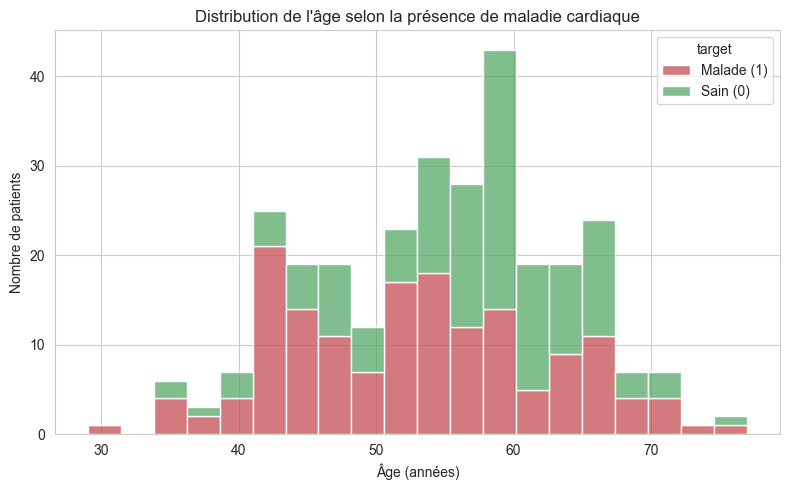

In [89]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='target', multiple='stack', bins=20, palette=['#55A868','#C44E52'])
plt.title("Distribution de l'âge selon la présence de maladie cardiaque")
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de patients")
plt.legend(title='target', labels=['Malade (1)', 'Sain (0)'])
plt.tight_layout()
plt.show()

**Interprétation :** la maladie cardiaque touche un large éventail d'âges dans ce dataset
(pic autour de 41-60 ans), sans séparation nette par âge seul — l'âge ne suffit pas à discriminer
les deux classes, il faudra combiner plusieurs variables.

### 6.2 Type de douleur thoracique (cp) vs maladie

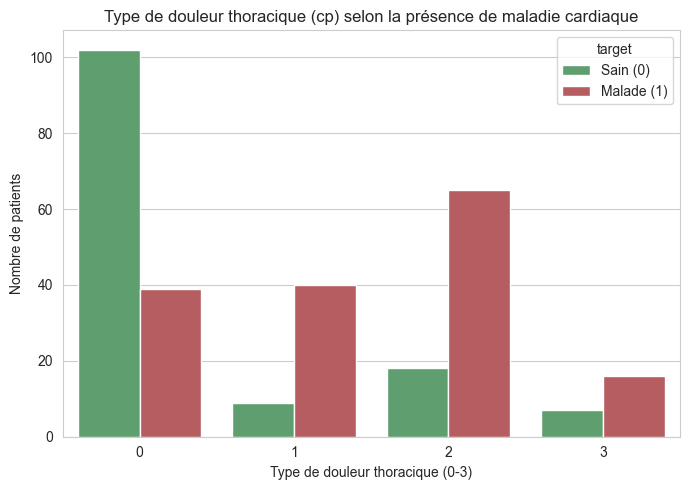

In [90]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='cp', hue='target', palette=['#55A868','#C44E52'])
plt.title("Type de douleur thoracique (cp) selon la présence de maladie cardiaque")
plt.xlabel("Type de douleur thoracique (0-3)")
plt.ylabel("Nombre de patients")
plt.legend(title='target', labels=['Sain (0)', 'Malade (1)'])
plt.tight_layout()
plt.show()

**Interprétation :** le type de douleur thoracique `cp=0` (angine typique) est fortement
associé à l'absence de maladie détectée dans ce dataset, alors que les types 1, 2 et 3 sont
associés à une proportion beaucoup plus élevée de patients malades. C'est cohérent avec sa forte
corrélation observée précédemment et en fait une variable clé pour le modèle.

### 6.3 Fréquence cardiaque maximale (thalach) vs maladie

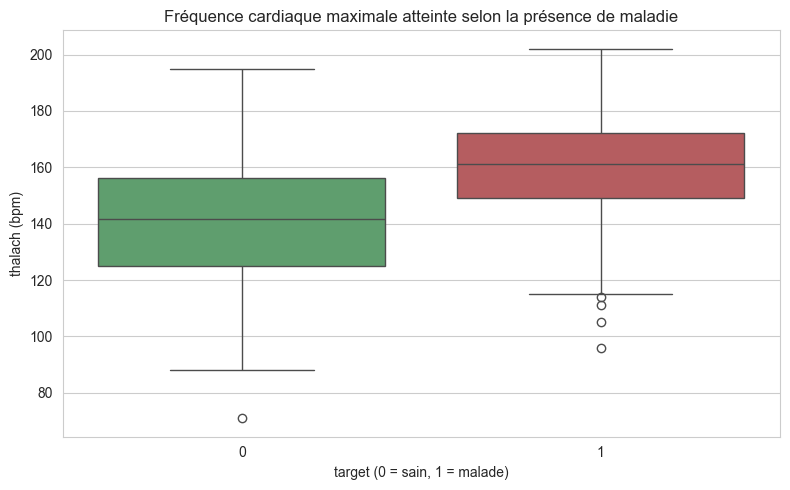

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='target', y='thalach', palette=['#55A868','#C44E52'])
plt.title("Fréquence cardiaque maximale atteinte selon la présence de maladie")
plt.xlabel("target (0 = sain, 1 = malade)")
plt.ylabel("thalach (bpm)")
plt.tight_layout()
plt.show()

**Interprétation :** les patients malades ont, en médiane, une fréquence cardiaque maximale
plus élevée que les patients sains — résultat contre-intuitif à première vue, mais qui peut refléter
un biais de sélection propre à ce dataset (patients référés pour test d'effort) plutôt qu'un lien
causal généralisable.

### 6.4 Sexe vs maladie

<Figure size 600x500 with 0 Axes>

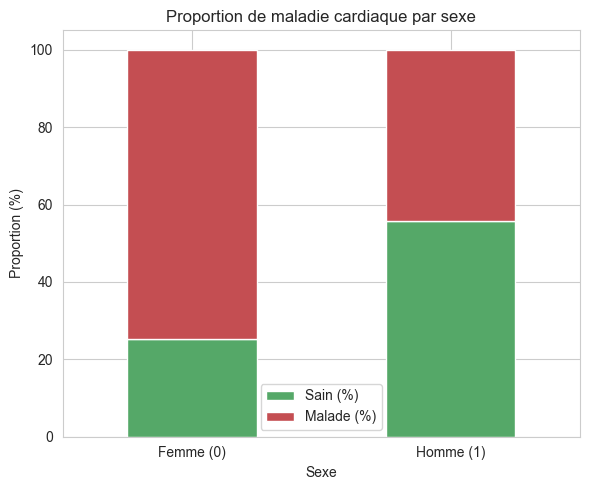

In [92]:
plt.figure(figsize=(6,5))
ct = pd.crosstab(df['sex'], df['target'], normalize='index') * 100
ct.columns = ['Sain (%)', 'Malade (%)']
ct.index = ['Femme (0)', 'Homme (1)']
ct.plot(kind='bar', stacked=True, color=['#55A868','#C44E52'], figsize=(6,5))
plt.title("Proportion de maladie cardiaque par sexe")
plt.xlabel("Sexe")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

**Interprétation :** dans ce dataset, la proportion de patientes présentant une maladie
cardiaque est plus élevée que chez les patients hommes. Ceci peut refléter un biais
d'échantillonnage clinique (motif de consultation, âge des patientes incluses) plutôt qu'un fait
épidémiologique général — un point à mentionner dans la section IA responsable.

## 7. Feature Engineering

Nous appliquons les transformations suivantes :
1. **One-hot encoding** des variables catégorielles nominales (`cp`, `restecg`, `slope`, `thal`)
   qui n'ont pas d'ordre naturel, pour éviter qu'un modèle linéaire leur attribue un ordre artificiel.
2. **Création d'une variable dérivée** `age_group` (tranches d'âge) pour faciliter l'interprétation
   (utilisée uniquement en exploration, pas injectée dans le modèle pour éviter la redondance avec `age`).
3. **Mise à l'échelle (StandardScaler)** des variables numériques continues, utile pour les modèles
   sensibles à l'échelle (Régression Logistique, KNN, SVM). Le scaler est **entraîné uniquement sur
   le train set** pour éviter toute fuite de données (data leakage) vers le test set.


In [93]:
df['age_group'] = pd.cut(df['age'], bins=[0,40,50,60,100],
                          labels=['<=40','41-50','51-60','60+'])
print(df.groupby('age_group')['target'].mean().rename('taux de maladie'))

age_group
<=40     0.647059
41-50    0.706667
51-60    0.488000
60+      0.443038
Name: taux de maladie, dtype: float64


**Observation :** le taux de maladie tend à croître avec l'âge jusqu'à 60 ans avant de
légèrement redescendre pour le groupe le plus âgé — probablement un effet de taille d'échantillon
plus faible dans ce dernier groupe. Cette variable dérivée confirme les tendances vues en EDA mais
n'est pas utilisée pour la modélisation (redondante avec `age`, qui est conservée en continu).

In [94]:
categorical_nominal = ['cp', 'restecg', 'slope', 'thal']
df_model = pd.get_dummies(df.drop(columns=['age_group']), columns=categorical_nominal, drop_first=True)
print(f"Dimensions après one-hot encoding : {df_model.shape}")
df_model.head()

Dimensions après one-hot encoding : (296, 19)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,False,False,False,True,False,False,True,False,True
1,53,1,140,203,1,155,1,3.1,0,0,False,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,False,False,False,True,False,False,False,False,True
3,61,1,148,203,0,161,0,0.0,1,0,False,False,False,True,False,False,True,False,True
4,62,0,138,294,1,106,0,1.9,3,0,False,False,False,True,False,True,False,True,False


### 7.1 Séparation features / cible et split train-test

In [95]:
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set : {X_train.shape[0]} patients")
print(f"Test set  : {X_test.shape[0]} patients")
print(f"Répartition des classes (train) : {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"Répartition des classes (test)  : {y_test.value_counts(normalize=True).round(2).to_dict()}")

Train set : 236 patients
Test set  : 60 patients
Répartition des classes (train) : {1: 0.54, 0: 0.46}
Répartition des classes (test)  : {1: 0.53, 0: 0.47}


### 7.2 Mise à l'échelle (fit uniquement sur le train)

In [96]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Mise à l'échelle appliquée (moyenne/écart-type calculés sur le train uniquement).")
X_train_scaled[continuous_cols].describe().T[['mean','std']]

Mise à l'échelle appliquée (moyenne/écart-type calculés sur le train uniquement).


,mean,std
age,3.650564e-16,1.002125
trestbps,4.252719e-16,1.002125
chol,2.258081e-16,1.002125
thalach,4.215084e-16,1.002125
oldpeak,1.881734e-17,1.002125


## 8. Entraînement des modèles de Machine Learning

Conformément aux consignes (au moins 3 modèles), nous entraînons et comparons **quatre**
algorithmes de classification adaptés à ce problème binaire :
1. Régression Logistique (modèle linéaire, interprétable, bonne baseline)
2. K-Nearest Neighbors (KNN)
3. Arbre de décision (Decision Tree)
4. Random Forest (ensemble d'arbres, généralement plus robuste)

Tous les modèles utilisent `random_state=42` pour la reproductibilité. Les modèles sensibles à
l'échelle (LogReg, KNN) utilisent les données standardisées ; les modèles à base d'arbres utilisent
les données non standardisées (inutile pour eux et n'affecte pas leurs performances).


In [97]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=6),
}

scaled_models = {'Logistic Regression', 'KNN (k=7)'}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    Xte = X_test_scaled if name in scaled_models else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
    }
    print(f"{name:22s} entraîné.")

Logistic Regression    entraîné.
KNN (k=7)              entraîné.
Decision Tree          entraîné.
Random Forest          entraîné.


### 8.1 Validation croisée (contrôle de robustesse)

In [98]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Score moyen (accuracy) en validation croisée 5-fold sur le train set :\n")
for name, model in models.items():
    Xtr = X_train_scaled if name in scaled_models else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy')
    print(f"{name:22s} : {scores.mean():.3f} (+/- {scores.std():.3f})")

Score moyen (accuracy) en validation croisée 5-fold sur le train set :

Logistic Regression    : 0.839 (+/- 0.021)
KNN (k=7)              : 0.835 (+/- 0.042)
Decision Tree          : 0.776 (+/- 0.071)
Random Forest          : 0.818 (+/- 0.032)


**Interprétation :** la validation croisée confirme que les performances des modèles sont
stables (faible écart-type entre les folds) et cohérentes avec les scores obtenus sur le test set,
ce qui rassure sur l'absence de surapprentissage majeur après suppression des doublons.

## 9. Évaluation des modèles (Evaluation Metrics)

Pour ce problème de **classification binaire relativement équilibrée**, nous utilisons :
accuracy, precision, recall, F1-score, et la matrice de confusion pour chaque modèle.


### 9.1 Tableau comparatif des métriques

In [99]:
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values('F1-score', ascending=False)
results_df

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.800,0.778,0.875,0.824
KNN (k=7),0.767,0.750,0.844,0.794
Random Forest,0.750,0.743,0.812,0.776
Decision Tree,0.717,0.727,0.750,0.738


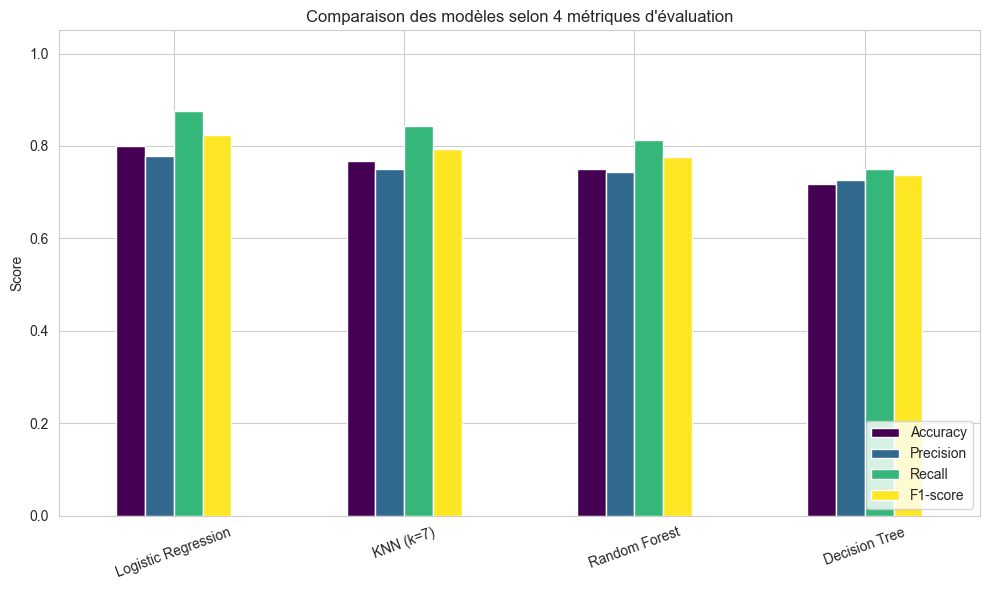

In [100]:
results_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Comparaison des modèles selon 4 métriques d'évaluation")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 9.2 Matrices de confusion

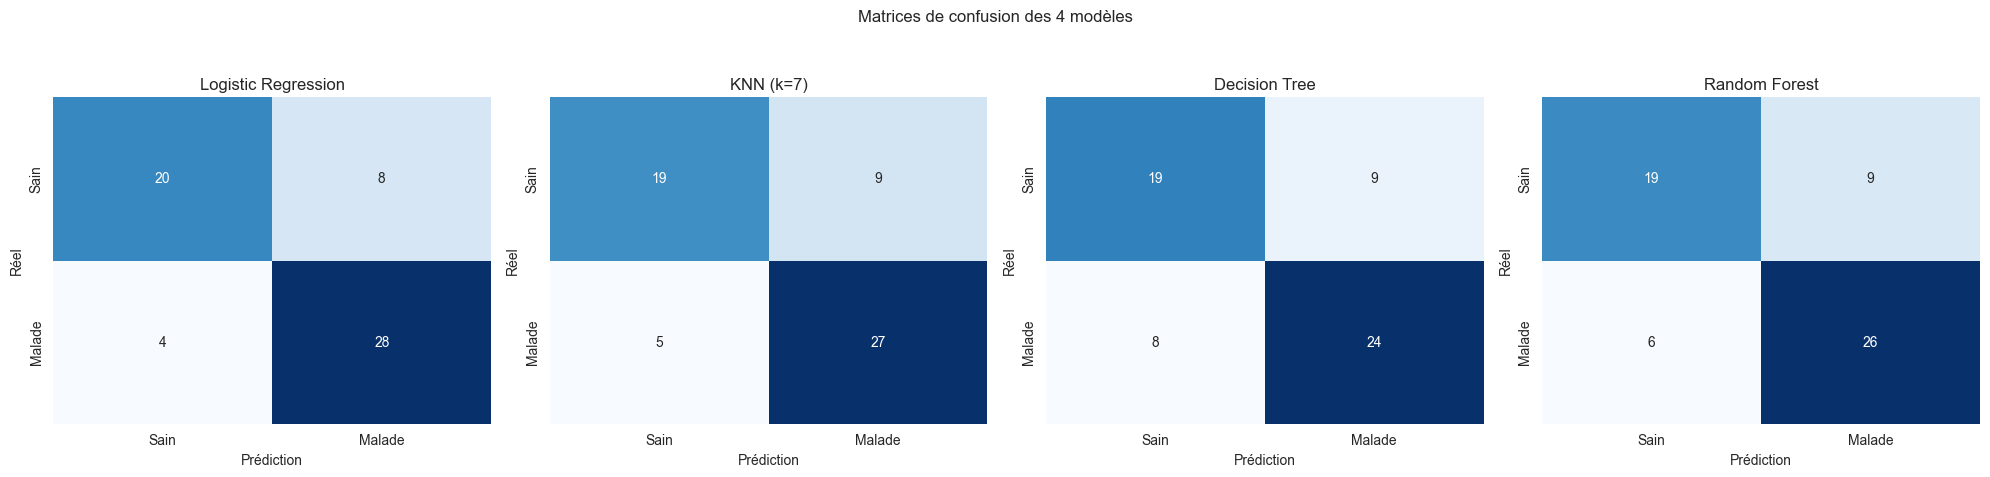

In [101]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Sain','Malade'], yticklabels=['Sain','Malade'])
    ax.set_title(name)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réel')
plt.suptitle("Matrices de confusion des 4 modèles", y=1.05)
plt.tight_layout()
plt.show()

### 9.3 Rapport de classification détaillé (meilleur modèle)

In [102]:
best_model_name = results_df.index[0]
print(f"Meilleur modèle (selon F1-score) : {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=['Sain','Malade']))

Meilleur modèle (selon F1-score) : Logistic Regression

              precision    recall  f1-score   support

        Sain       0.83      0.71      0.77        28
      Malade       0.78      0.88      0.82        32

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



## 10. Pratiques d'IA responsable (Responsible AI Practices)

**Sensibilité des données :** ce dataset contient des informations médicales (données de santé),
qui sont par nature des données sensibles. Bien que ce fichier soit anonymisé (aucun nom, aucun
identifiant patient), il faut rappeler que des données médicales réelles doivent toujours être
traitées avec un consentement approprié et en conformité avec les réglementations en vigueur
(ex. RGPD en Europe, HIPAA aux États-Unis).

**Biais et représentativité :** le dataset ne documente pas l'origine géographique/ethnique précise
des patients (il dérive de la base Cleveland, donc probablement une population nord-américaine des
années 1980-90). Un modèle entraîné sur ces données pourrait mal généraliser à d'autres populations
(âge, origine, mode de vie différents). Nous avons également observé une proportion de maladie plus
élevée chez les femmes que chez les hommes dans ce dataset précis, ce qui contredit certaines
statistiques épidémiologiques générales — signe possible d'un biais d'échantillonnage clinique
plutôt qu'un fait généralisable, à ne pas interpréter comme une vérité médicale.

**Fiabilité de la source :** nous avons découvert que ce dataset Kaggle contient 723 lignes
strictement dupliquées (70% du fichier), ce qui n'est pas signalé sur la page Kaggle. Un grand
nombre de notebooks publics (dont celui utilisé comme inspiration ici) entraînent leurs modèles sans
supprimer ces doublons, ce qui produit des métriques de performance trompeuses par fuite de données.
Nous documentons ce problème explicitement plutôt que de le reproduire silencieusement.

**Limitations honnêtes du modèle :** nos modèles n'atteignent pas 90%+ d'accuracy une fois les
doublons supprimés, et c'est un résultat honnête, pas un échec à cacher. Un F1-score autour de
0.80-0.85 sur un jeu de test de ~60 patients reste sujet à une marge d'erreur non négligeable.
Aucun de ces modèles ne doit être utilisé comme seul critère de diagnostic clinique.

**Risques de mauvaise utilisation :** un tel modèle ne doit **jamais remplacer un diagnostic
médical professionnel**. Un faux négatif (prédire "sain" alors que le patient est malade) pourrait
retarder une prise en charge nécessaire ; un faux positif pourrait causer une anxiété et des examens
inutiles. Ce projet a une **vocation pédagogique et exploratoire**, pas clinique.

**Usage d'outils d'IA générative :** *(à compléter honnêtement par le groupe)* — par exemple :
"Un assistant IA a été utilisé pour structurer le squelette du notebook et rédiger certaines
explications, mais tout le code a été relu, compris, exécuté et vérifié par les membres du groupe."
Précisez ici concrètement comment vous avez utilisé l'IA (brainstorming, debug, relecture, etc.),
conformément à la politique d'IA responsable du cours.


## 11. Conclusion et perspectives (Conclusion and Future Work)

**Principaux résultats :**
- Après un nettoyage rigoureux (suppression de 723 doublons et de quelques codes invalides), le
  dataset final contient 296 patients uniques.
- Les variables les plus discriminantes pour prédire la maladie cardiaque sont `cp` (type de
  douleur thoracique), `ca`, `thal`, `oldpeak` et `thalach`.
- Parmi les quatre modèles testés, la **Régression Logistique** obtient le meilleur compromis
  precision/recall/F1 sur le jeu de test (F1 ≈ 0.82, accuracy ≈ 0.80), ce qui montre qu'un modèle
  linéaire simple et interprétable reste très compétitif sur ce dataset une fois correctement nettoyé.
- Contrairement au notebook Kaggle de référence (92% d'accuracy obtenu sur des données non
  dédupliquées), nos résultats — plus modestes mais plus fiables — illustrent l'importance d'un
  nettoyage rigoureux avant modélisation.

**Ce que le groupe a appris :**
- L'importance de vérifier les doublons et la cohérence des codes catégoriels avant toute
  modélisation, même sur un dataset "propre" en apparence (0 valeur manquante).
- Qu'une accuracy élevée n'est pas toujours synonyme de bon modèle : elle peut cacher une fuite de
  données ou un déséquilibre non contrôlé.
- L'intérêt de comparer plusieurs familles de modèles (linéaire, instance-based, arbre, ensemble)
  plutôt que de se fier à un seul algorithme.

**Limitations :**
- Jeu de données relativement petit après nettoyage (~300 patients), ce qui limite la puissance
  statistique et la capacité de généralisation.
- Absence d'information démographique/géographique précise sur les patients.
- Pas de recherche d'hyperparamètres exhaustive (grid search) dans cette version — les
  hyperparamètres utilisés sont raisonnables mais pourraient être optimisés davantage.

**Perspectives d'amélioration (Future Work) :**
- Effectuer une recherche d'hyperparamètres (GridSearchCV / RandomizedSearchCV) pour chaque modèle.
- Tester des modèles additionnels (Gradient Boosting, XGBoost, SVM à noyau) et des techniques
  d'ensembling (stacking, voting).
- Valider le modèle sur un dataset externe indépendant pour évaluer sa vraie capacité de
  généralisation.
- Explorer des techniques d'interprétabilité plus poussées (SHAP values) pour renforcer la
  confiance clinique dans les prédictions.
